In [1]:
import numpy as np

from quantitative.quantitative_blocks import model
from plotting import plots_quantitative

# Main calibration

The model has three specifications:
 - Basic model
- Durables model
 - Inventories model

First set the parameters that are common across model specifications. Then, we set the parameters that differ across specifications.

In [2]:
# Common parameters
r_ss = 0.005/4  # quarterly real interest rate

common = {
       'beta': 1/(1 + r_ss),            # Discount factor
       'delta': 0.20 / 4,               # Depreciation rate of durables
       'phi': 0.5,                      # Frisch elasticity of labor supply
       'eta': 1.15,                     # Elasticity of import substitution
       'gamma': 1.5,                    # Elasticity of foreign demand
       'eps_D': 8.2,                    # Elasticity of durables demand
       'ups': 1,                        # Elasticity of substitution between inventory and drawdown
       'rho_i': 0.0,                    # Inertia in Taylor rule
       'phi_pi': 1.5,                   # Taylor rule response to wage inflation
       'phi_x': 0.0,                    # Taylor rule response to labor wedge
       'kappa': 0.05,                   # Phillips curve slope,
       'openness': 0.11,                # Imports / Output
}

# Note: eps_S calibrated internally

Set additional parameters used in the different model versions:

In [3]:
share_durables = 0.11        # Share of durable expenditure in consumption
inv_to_sales = 0.33           # Inventory to sales ratio
sigma_dur = 1.0              # EIS in model with durables
sigma_basic = 1.79           # EIS in basic model without durables

Next, create three versions of the calibration.

In [4]:
from quantitative.quantitative_steadystate import get_steady_states
ss_dic = get_steady_states(common, sigma_basic, sigma_dur, share_durables, inv_to_sales)
ss_dic.keys()

dict_keys(['basic', 'durables', 'inventories'])

# Compute impulse responses

Set the import tariff shocks

In [5]:
# Set parameters for shock
dtau = 10  # size of shock
rho = 0.75
T = 50
shock = dtau * rho ** np.arange(T)

Compute all impulse responses to uni-lateral tariff shock.

In [6]:
irf_dic = {}

for name, ss in ss_dic.items():

    irf_dic[name] = {}

    ### Taylor rule
    irf_dic[name]['taylor'] = model.solve_impulse_linear(ss, unknowns=['pi_w', 'E', 'Y', 'G', 'i', 'C_ND_corr2', 'E_corr2'], targets=['nkpc_res', 'uip_cond', 'goods_mkt', 'G_cond', 'i_res', 'C_ND_corr_cond', 'E_corr_cond'], inputs={'tau': shock})

    ### Constant E
    irf_dic[name]['fixed E'] = model.solve_impulse_linear(ss, unknowns=['pi_w', 'Y', 'G', 'C_ND_corr2'],
                                                          targets=['nkpc_res', 'goods_mkt', 'G_cond', 'C_ND_corr_cond'],
                                                        inputs={'tau': shock})
    irf_dic[name]['fixed E']['E'] = 0 * np.arange(T)
    irf_dic[name]['fixed E']['i'] = 0 * np.arange(T)

    ### Natural allocation
    irf_dic[name]['natural'] = model.solve_impulse_linear(ss, unknowns=['i', 'Y', 'G', 'E', 'C_ND_corr2', 'E_corr2'], targets=['nkpc_res', 'uip_cond', 'goods_mkt', 'G_cond', 'C_ND_corr_cond', 'E_corr_cond'], inputs={'tau': shock})
    irf_dic[name]['natural']['W'] = 0*np.arange(T)

Next, compute impulse responses in the basic model with retaliation.

In [7]:
irf_retaliation = {}

### Taylor rule
irf_retaliation['taylor'] = model.solve_impulse_linear(ss_dic['basic'], unknowns=['pi_w', 'E', 'Y', 'G', 'i', 'C_ND_corr2', 'E_corr2'], targets=['nkpc_res', 'uip_cond', 'goods_mkt', 'G_cond', 'i_res', 'C_ND_corr_cond', 'E_corr_cond'], inputs={'tau': shock, 'taustar': shock})

### Constant E
irf_retaliation['fixed E'] = model.solve_impulse_linear(ss_dic['basic'], unknowns=['pi_w', 'Y', 'G', 'C_ND_corr2'],
                                                      targets=['nkpc_res', 'goods_mkt', 'G_cond', 'C_ND_corr_cond'],
                                                    inputs={'tau': shock, 'taustar': shock})
irf_retaliation['fixed E']['E'] = 0 * np.arange(T)
irf_retaliation['fixed E']['i'] = 0 * np.arange(T)

### Natural allocation
irf_retaliation['natural'] = model.solve_impulse_linear(ss_dic['basic'], unknowns=['i', 'Y', 'G', 'E', 'C_ND_corr2', 'E_corr2'], targets=['nkpc_res', 'uip_cond', 'goods_mkt', 'G_cond', 'C_ND_corr_cond', 'E_corr_cond'], inputs={'tau': shock, 'taustar': shock})
irf_retaliation['natural']['W'] = 0*np.arange(T)

# Figure 10: Basic model

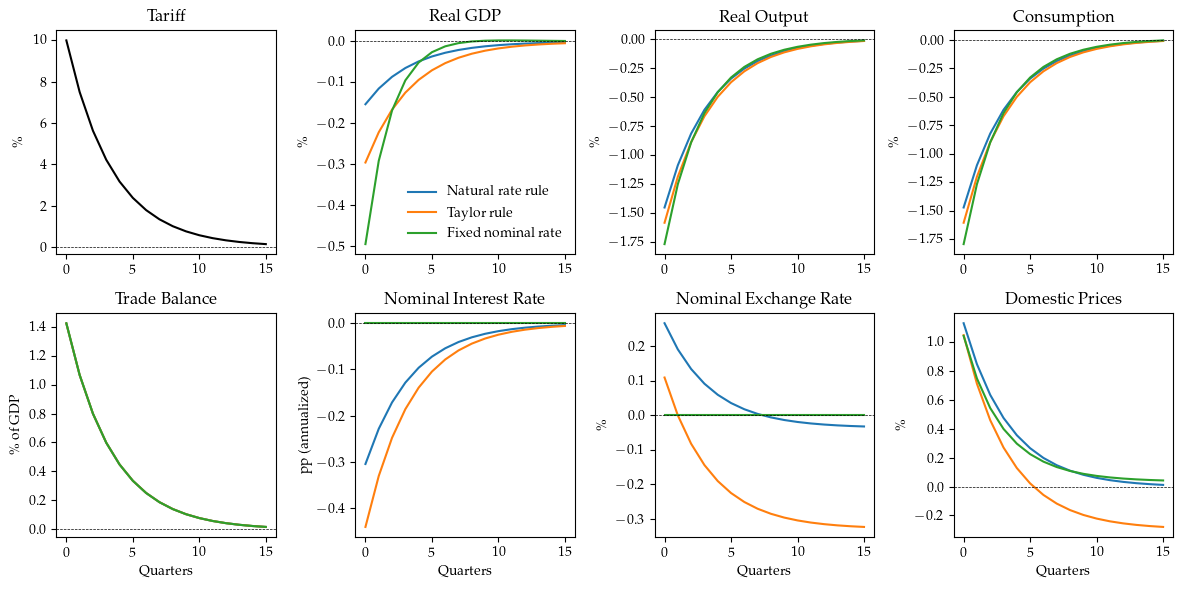

In [8]:
plots_quantitative.plot_irfs_quant_model("fig10_quant_impulse_comparison", ss_dic['basic'], irf_dic['basic'])

# Table 3: Impact effects of tariff shock

In [9]:
plots_quantitative.table_impact_effect_tariffs(ss_dic['basic'], irf_dic['basic'], irf_retaliation)

-0.49%	-0.30%	-0.15%	-1.86%	-1.02%	-0.53%
1.43%	1.43%	1.43%	-0.22%	-0.22%	-0.23%
0.00pp	-0.44pp	-0.30pp	0.00pp	-1.53pp	-1.06pp
0.00%	0.11%	0.27%	0.00%	0.51%	1.06%


# Figure 11: Comparison with durables model

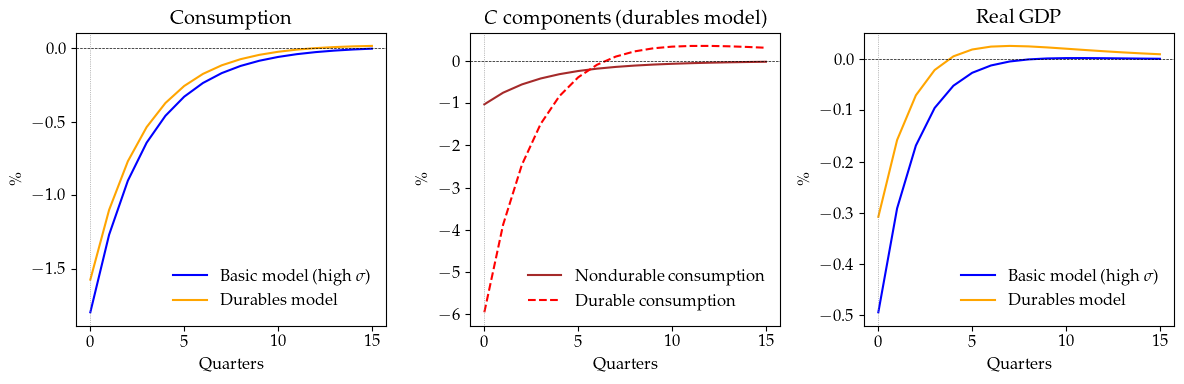

In [10]:
plots_quantitative.plot_irfs_comparison_durables(ss_dic['basic'], ss_dic['durables'], irf_dic['basic']['fixed E'], irf_dic['durables']['fixed E'])

# Figure 12: Anticipated tariff shock in durables model

In [11]:
period_of_shock = 3
irfs_anticipated = {}
for name, ss in ss_dic.items():
    irfs_anticipated[name] = model.solve_impulse_linear(ss, unknowns=['pi_w', 'Y', 'G', 'C_ND_corr2'],
                                                          targets=['nkpc_res', 'goods_mkt', 'G_cond', 'C_ND_corr_cond'],
                                                        inputs={'tau': np.concatenate((np.zeros(period_of_shock), shock[:-period_of_shock]))})

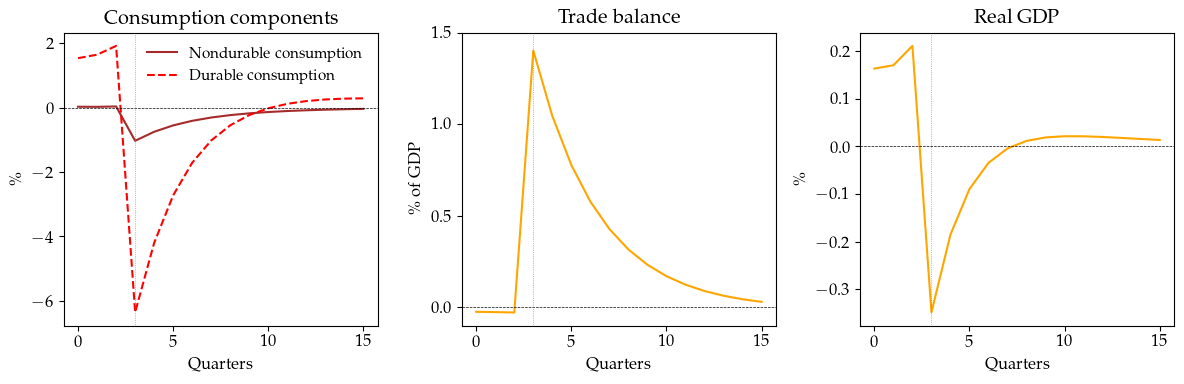

In [12]:
plots_quantitative.plot_irfs_anticipated_tariff_durables(ss_dic['durables'], irfs_anticipated['durables'], period_of_shock)

# Figure 13: Comparison with model with inventories

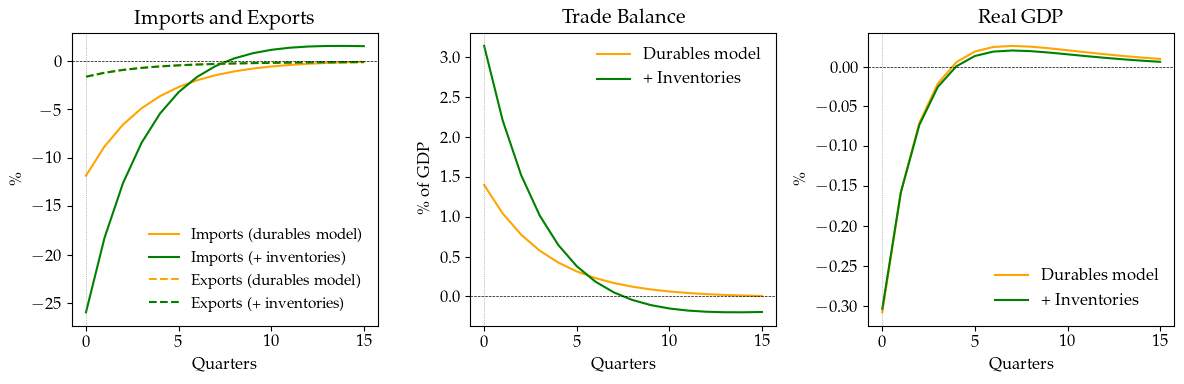

In [13]:
plots_quantitative.plot_comparison_inventories("fig13_comparison_inventories", ss_dic['durables'], ss_dic['inventories'], irf_dic['durables']['fixed E'], irf_dic['inventories']['fixed E'])

# Figure 14: Anticipated tariff shock in inventories model


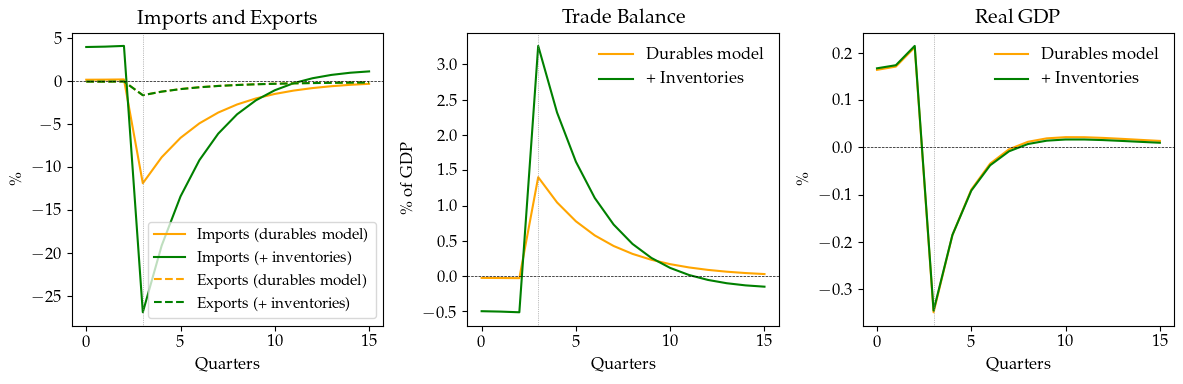

In [14]:
plots_quantitative.plot_comparison_inventories("fig14_comparison_inventories_anticipated", ss_dic['durables'], ss_dic['inventories'], irfs_anticipated['durables'], irfs_anticipated['inventories'], period_of_shock=3)

# Figure 15: Vary anticipation period

In [15]:
horizons = np.arange(9)

In [16]:
irfs_list = []
for period_of_shock in horizons:
    if period_of_shock == 0:
        irfs_here = irf_dic['inventories']['fixed E']
    else:
        irfs_here = model.solve_impulse_linear(ss_dic['inventories'], unknowns=['pi_w', 'Y', 'G', 'C_ND_corr2'],
                                                              targets=['nkpc_res', 'goods_mkt', 'G_cond', 'C_ND_corr_cond'],
                                                            inputs={'tau': np.concatenate((np.zeros(period_of_shock), shock[:-period_of_shock]))})
    irfs_list.append(irfs_here)

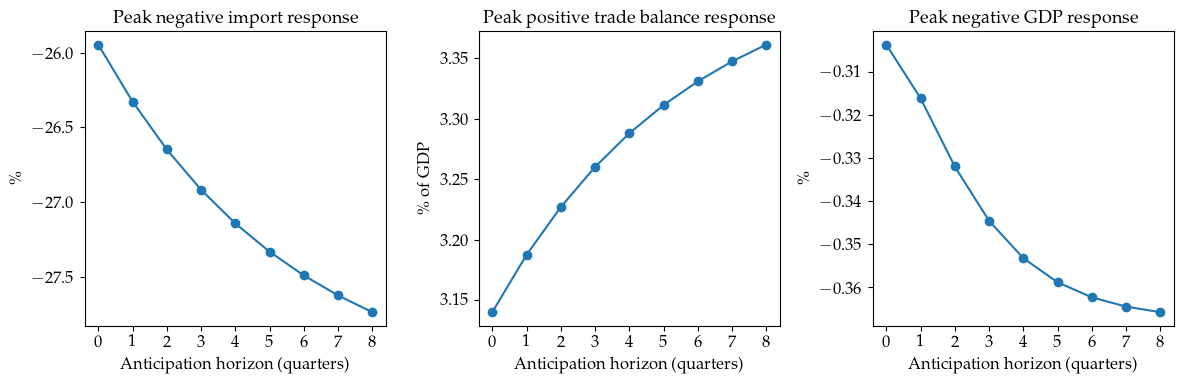

In [17]:
plots_quantitative.plot_peaks_with_anticipation_horizon(ss_dic['inventories'], irfs_list, horizons)

# Figures 19 to 21: Plot some IRFs of quantitative models

These are variants of the IRFs for the quantitative environment in figure 10 in the main text, under various alternative assumptions and models.

First figure 19, for if there is retaliation:

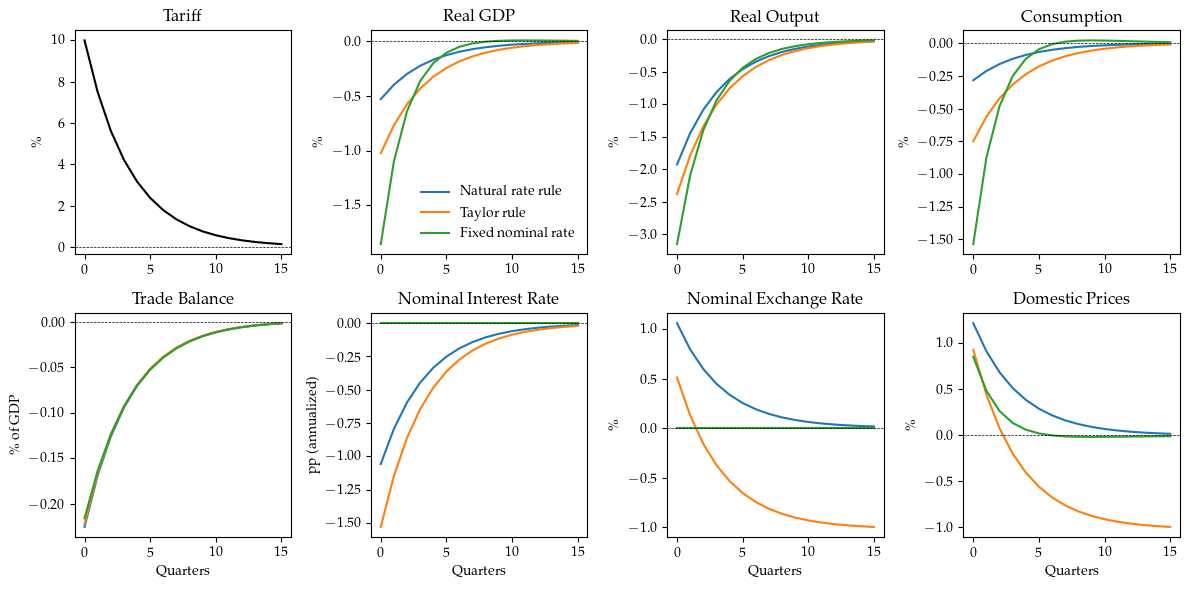

In [18]:
plots_quantitative.plot_irfs_quant_model("fig19_irfs_retaliation_fixedE", ss_dic['basic'], irf_retaliation)

Then figure 20, model with durables and not inventories (back to a unilateral shock):

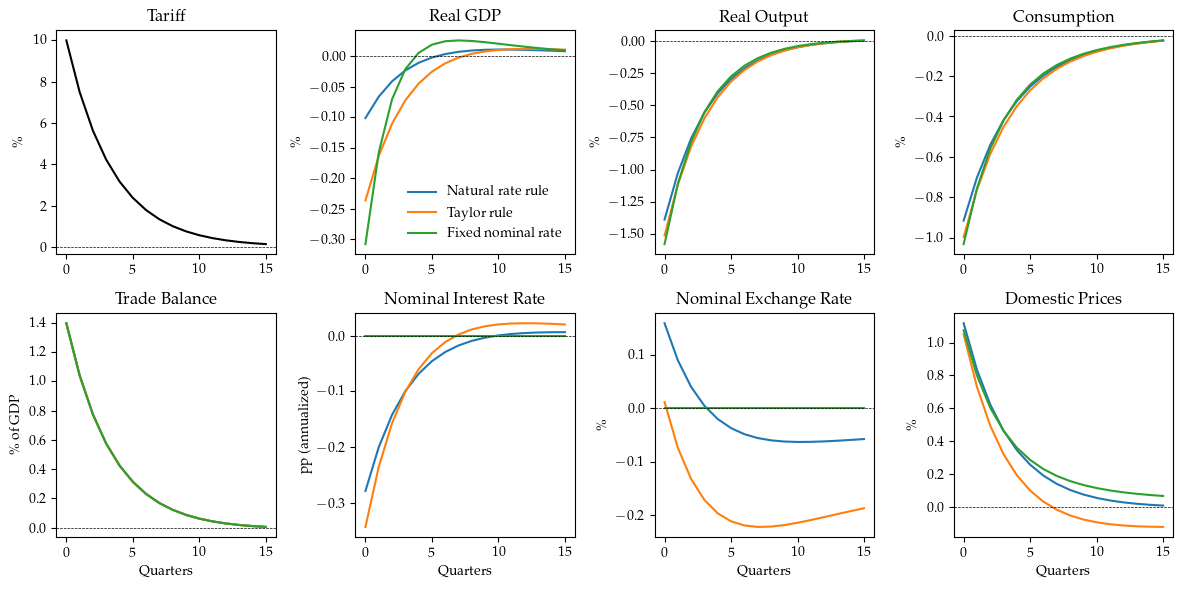

In [19]:
plots_quantitative.plot_irfs_quant_model("fig20_irfs_durables", ss_dic['durables'], irf_dic['durables'])

Then figure 21, model with both durables and inventories:

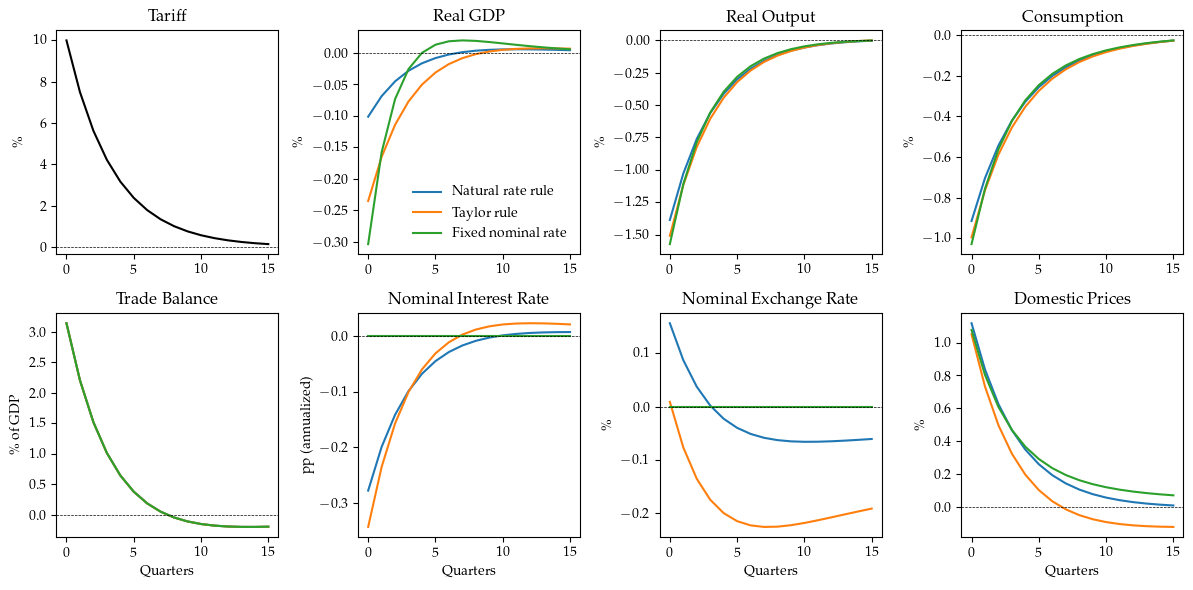

In [20]:
plots_quantitative.plot_irfs_quant_model("fig21_irfs_inventories", ss_dic['inventories'], irf_dic['inventories'])